**Import dataset**

In [ ]:
import pandas as pd
import ast

df = pd.read_csv("datasets/data.csv")

df = df.dropna(subset=['clean_labels'])

# แปลง label string -> list
df["clean_labels"] = df["clean_labels"].apply(ast.literal_eval)

texts = df["Abstracts"].astype(str)
labels = df["clean_labels"]

**การจัดการ Label (MultiLabelBinarizer)** : เปลี่ยนชื่อหมวดหมู่ที่เดิมเป็นรูปแบบ String ให้กลายเป็นลักษณะของตัวเลข (One-hot encoding vector)

In [2]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(labels)

num_classes = len(mlb.classes_)

print("Classes:", mlb.classes_)

Classes: ['cs.AI' 'cs.CV' 'cs.LG' 'stat.ML']


**การทำ Tokenization (BERT Tokenizer)** : (Tokenize) และแปลงคำศัพท์เป็น ID ตามพจนานุกรมของ bert-base-uncased


*   AX_LEN = 128: กำหนดความยาวสูงสุดของประโยคที่โมเดลจะรับ
*   padding=True: ทำให้ทุกประโยคมีความยาวเท่ากัน (128 คำ)
* truncation=True: ตัดส่วนที่เกิน 128 คำออก เพื่อป้องกันไม่ให้ Memory เต็ม



In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 256

encodings = tokenizer(
    texts.tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**PaperDataset(Dataset)** : นี่คือการสร้างโครงสร้างข้อมูลแบบ Custom เพื่อให้ PyTorch ดึงข้อมูลไปใช้ได้อย่างเป็นระเบียบ


*   __init__: ทำหน้าที่รับข้อมูล encodings (ที่ได้จาก BERT) และ labels มาเก็บไว้ในตัวแปรของคลาส
*   __getitem__: หัวใจหลักของส่วนนี้ คือการบอกว่า "ถ้าต้องการข้อมูลลำดับที่ idx ให้ส่งอะไรกลับไป


*   __len__: บอกขนาดของชุดข้อมูลทั้งหมด เพื่อให้โมเดลรู้ว่า 1 รอบการเทรน (Epoch) ต้องดึงข้อมูลกี่ครั้ง




In [4]:
import torch
from torch.utils.data import Dataset

class PaperDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels).float()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

In [5]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    range(len(texts)),
    test_size=0.2,
    random_state=42
)

train_enc = {k:v[train_idx] for k,v in encodings.items()}
test_enc = {k:v[test_idx] for k,v in encodings.items()}

train_labels = y[train_idx]
test_labels = y[test_idx]

**DataLoader**

In [6]:
from torch.utils.data import DataLoader

train_dataset = PaperDataset(train_enc, train_labels)
test_dataset = PaperDataset(test_enc, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# **Train model**

In [7]:
import torch.nn as nn
import torch

class TextCNN(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_classes):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, 100, kernel_size=3),
            nn.Conv1d(embed_dim, 100, kernel_size=4),
            nn.Conv1d(embed_dim, 100, kernel_size=5)
        ])

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(300, num_classes)

    def forward(self, input_ids):

        x = self.embedding(input_ids)

        x = x.permute(0,2,1)

        convs = [torch.relu(conv(x)) for conv in self.convs]

        pools = [torch.max(c, dim=2)[0] for c in convs]

        x = torch.cat(pools, dim=1)

        x = self.dropout(x)

        logits = self.fc(x)

        return logits

In [8]:
vocab_size = tokenizer.vocab_size

model = TextCNN(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TextCNN(
  (embedding): Embedding(30522, 128)
  (convs): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=4, bias=True)
)

In [9]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=2e-4)

In [10]:
for epoch in range(100):

    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

Epoch 1 Loss: 0.4832588121767195
Epoch 2 Loss: 0.37974233447875777
Epoch 3 Loss: 0.35341434067928457
Epoch 4 Loss: 0.33733705809873316
Epoch 5 Loss: 0.32449679222709976
Epoch 6 Loss: 0.3180024659287342
Epoch 7 Loss: 0.30852042470004915
Epoch 8 Loss: 0.3002653023569097
Epoch 9 Loss: 0.2938201422562622
Epoch 10 Loss: 0.2882788618982818
Epoch 11 Loss: 0.28063256202589176
Epoch 12 Loss: 0.27395988887114703
Epoch 13 Loss: 0.2676871246330335
Epoch 14 Loss: 0.26081224131297337
Epoch 15 Loss: 0.2523204903009002
Epoch 16 Loss: 0.24380205319363607
Epoch 17 Loss: 0.23377452892614223
Epoch 18 Loss: 0.22597394031887882
Epoch 19 Loss: 0.21560276730397077
Epoch 20 Loss: 0.20251581774578548
Epoch 21 Loss: 0.19256352294813578
Epoch 22 Loss: 0.18088240077185658
Epoch 23 Loss: 0.17016639816465443
Epoch 24 Loss: 0.1582300619095424
Epoch 25 Loss: 0.14608354505999757
Epoch 26 Loss: 0.13849325309302046
Epoch 27 Loss: 0.1261384794313653
Epoch 28 Loss: 0.11959682504904452
Epoch 29 Loss: 0.11247834269210977
Epo

# **Model Evaluation**

In [11]:
model.eval()

all_preds = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        logits = model(input_ids)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).int()

        all_preds.append(preds.cpu())

In [12]:
from sklearn.metrics import f1_score
import torch

preds = torch.cat(all_preds).numpy()

f1_micro = f1_score(test_labels, preds, average="micro")

print("Micro F1:", f1_micro)

Micro F1: 0.8519712372923383


## Train history: loss และ accuracy

Epoch 1/20 - loss: 0.0167 - exact_match_acc: 0.9780
Epoch 2/20 - loss: 0.0158 - exact_match_acc: 0.9792
Epoch 3/20 - loss: 0.0161 - exact_match_acc: 0.9776
Epoch 4/20 - loss: 0.0157 - exact_match_acc: 0.9794
Epoch 5/20 - loss: 0.0156 - exact_match_acc: 0.9788
Epoch 6/20 - loss: 0.0152 - exact_match_acc: 0.9790
Epoch 7/20 - loss: 0.0151 - exact_match_acc: 0.9802
Epoch 8/20 - loss: 0.0161 - exact_match_acc: 0.9785
Epoch 9/20 - loss: 0.0152 - exact_match_acc: 0.9796
Epoch 10/20 - loss: 0.0148 - exact_match_acc: 0.9804
Epoch 11/20 - loss: 0.0152 - exact_match_acc: 0.9799
Epoch 12/20 - loss: 0.0149 - exact_match_acc: 0.9799
Epoch 13/20 - loss: 0.0147 - exact_match_acc: 0.9803
Epoch 14/20 - loss: 0.0152 - exact_match_acc: 0.9794
Epoch 15/20 - loss: 0.0142 - exact_match_acc: 0.9816
Epoch 16/20 - loss: 0.0141 - exact_match_acc: 0.9809
Epoch 17/20 - loss: 0.0149 - exact_match_acc: 0.9797
Epoch 18/20 - loss: 0.0149 - exact_match_acc: 0.9801
Epoch 19/20 - loss: 0.0136 - exact_match_acc: 0.9824
Ep

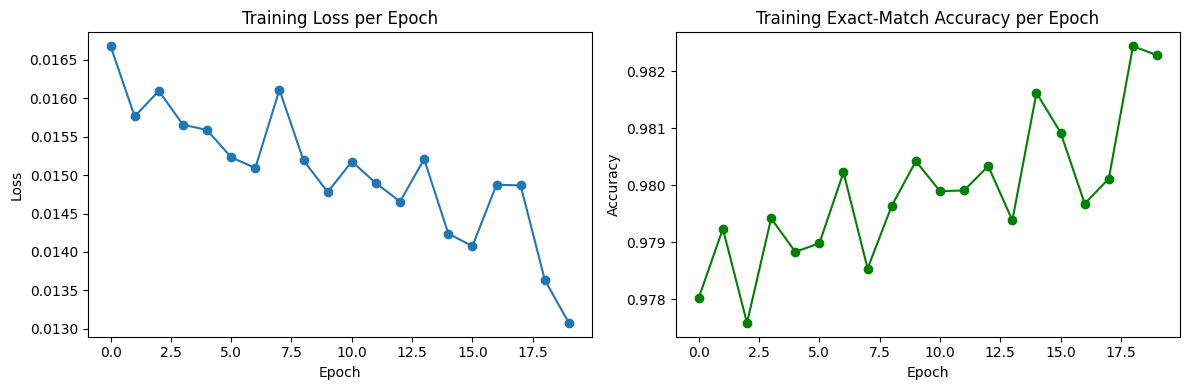

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ถ้าจะเทรนใหม่เพื่อเก็บ history ให้รันเซลล์นี้
NUM_EPOCHS = 20

train_loss_history = []
train_acc_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    batch_acc = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # multi-label prediction
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()

        # exact match accuracy ต่อ batch
        acc = accuracy_score(
            labels.detach().cpu().numpy().astype(int),
            preds.detach().cpu().numpy().astype(int)
        )
        batch_acc.append(acc)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = float(np.mean(batch_acc))

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - loss: {epoch_loss:.4f} - exact_match_acc: {epoch_acc:.4f}")

# plot loss + accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, marker="o")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, marker="o", color="green")
plt.title("Training Exact-Match Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

## ประเมินโมเดล: accuracy และ confusion matrix

Exact-match accuracy: 0.6334
Label-wise accuracy (1 - hamming loss): 0.8889


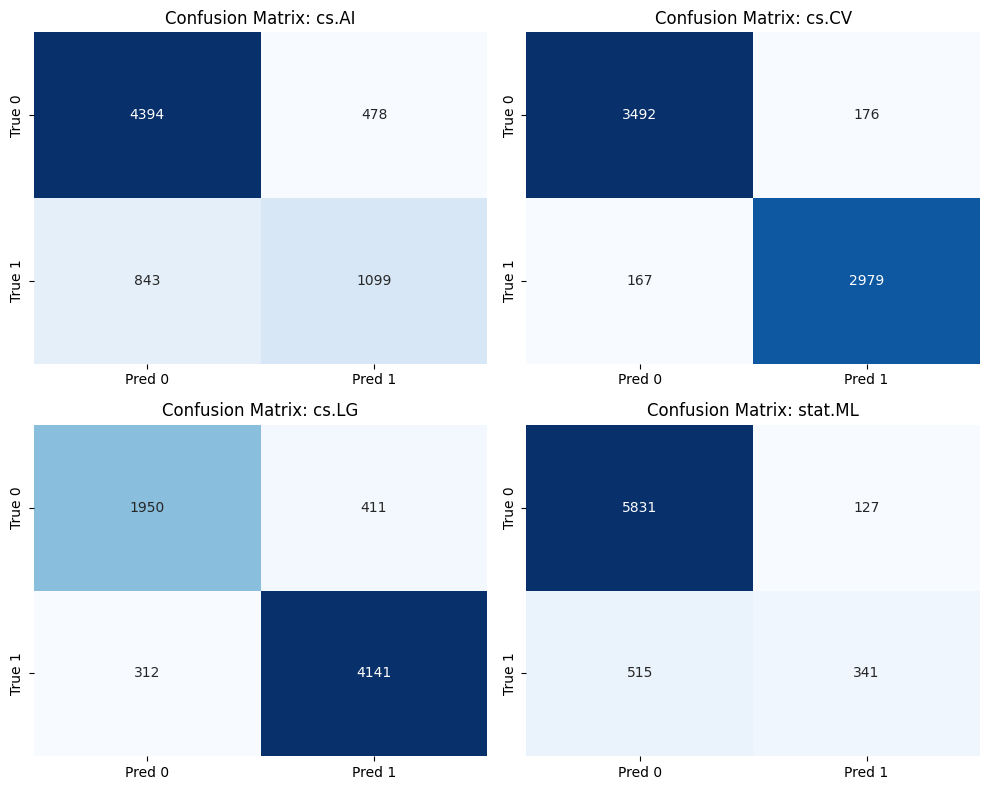

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, hamming_loss, multilabel_confusion_matrix

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()

        all_preds.append(preds.cpu().numpy())
        all_true.append(labels.cpu().numpy().astype(int))

y_pred = np.vstack(all_preds)
y_true = np.vstack(all_true)

# Accuracy แบบ exact match: ต้องทายถูกทุก label ใน 1 sample
exact_match_acc = accuracy_score(y_true, y_pred)

# อีกมุม: label-wise accuracy ผ่าน Hamming
label_wise_acc = 1 - hamming_loss(y_true, y_pred)

print(f"Exact-match accuracy: {exact_match_acc:.4f}")
print(f"Label-wise accuracy (1 - hamming loss): {label_wise_acc:.4f}")

# Confusion matrix แบบแยกราย label (one-vs-rest)
mcm = multilabel_confusion_matrix(y_true, y_pred)

n_classes = len(mlb.classes_)
cols = 2
rows = int(np.ceil(n_classes / cols))

plt.figure(figsize=(10, 4 * rows))
for i in range(n_classes):
    plt.subplot(rows, cols, i + 1)
    sns.heatmap(
        mcm[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix: {mlb.classes_[i]}")

plt.tight_layout()
plt.show()